This Jupyter Notebook, which represents the second part of the project, aims to address the need to forecast the monthly **HICP** using data from daily markets.

There are two key points to note here:

- **1. Date convention:** Monthly series are labelled with the first day of the month to which they refer (e.g. ‘2024-01-01’, which represents the whole of January). Therefore, when resampling the daily data, it must be grouped so that it aligns with the start of the month using the **MS (Month Start)** rule.
- **2. The HICP is an index, not a price:** The absolute value (e.g. 120.0) has no meaning on its own; what matters is the percentage change (inflation).

## Loading, Resampling and Merging the Data

We begin with the compact version of the data cleaning process from the first part of the project: resample the data to monthly averages and merge it with the inflation series (HICP).

In [1]:
# ==========================================
# 1. IMPORTS AND DATA LOADING
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data from the data folder
df = pd.read_csv('../data/energy_panel.csv', parse_dates=['date'])

# --- Preparation of market data (Daily to Monthly) ---
market_series = [
    'brent', 'wti', 'us_gasoline_spot', 
    'us_diesel_spot', 'heating_oil_ny', 'eurusd'
]

# Pivot, align dates (Forward Fill) and truncate to July 2006 --- PART 1 Related
df_markets = df[df['series_id'].isin(market_series)].pivot(index='date', columns='series_id', values='value')
all_b_days = pd.bdate_range(start=df_markets.index.min(), end=df_markets.index.max())
df_markets = df_markets.reindex(all_b_days).ffill().loc['2006-07-01':]

# RESAMPLING: Convert the daily series to monthly averages. 
# 'MS' (Month Start) for that to match with the label of the HICP.
df_markets_monthly = df_markets.resample('MS').mean()


# --- Preparation of HICP data (Monthly) ---
hicp_series = ['hicp_transport_fuels_it', 'hicp_heating_it', 'hicp_headline_it']

# Pivot the inflation variables
df_hicp = df[df['series_id'].isin(hicp_series)].pivot(index='date', columns='series_id', values='value')


# --- Join of the data ---
# Join (inner join) the features of the market with the HICP targets
df_part2 = df_markets_monthly.join(df_hicp, how='inner')

print(f"Dimensions of the aligned dataset: {df_part2.shape}")
display(df_part2.head())

Dimensions of the aligned dataset: (234, 9)


series_id,brent,eurusd,heating_oil_ny,us_diesel_spot,us_gasoline_spot,wti,hicp_headline_it,hicp_heating_it,hicp_transport_fuels_it
2006-07-01,73.674286,1.268367,1.947095,2.229190,2.264333,74.366190,85.8,90.2,87.0
2006-08-01,73.230435,1.281130,1.983739,2.233304,2.001391,73.043043,85.6,90.5,88.0
2006-09-01,61.958571,1.272743,1.712286,1.800667,1.568381,64.057143,86.2,88.8,83.3
2006-10-01,57.808182,1.261105,1.648000,1.784182,1.510227,58.893182,86.3,86.0,79.6
2006-11-01,58.761364,1.288141,1.646682,1.797682,1.562864,58.918636,86.4,85.5,79.0


## 2. Converting the HICP into inflation (target variable)

As is well known, ‘inflation is a rate of growth, not a level’. Therefore, if one attempts to predict the level directly, the model will suffer from stationarity issues. Consequently, the HICP must be converted into its monthly percentage change (month-on-month).

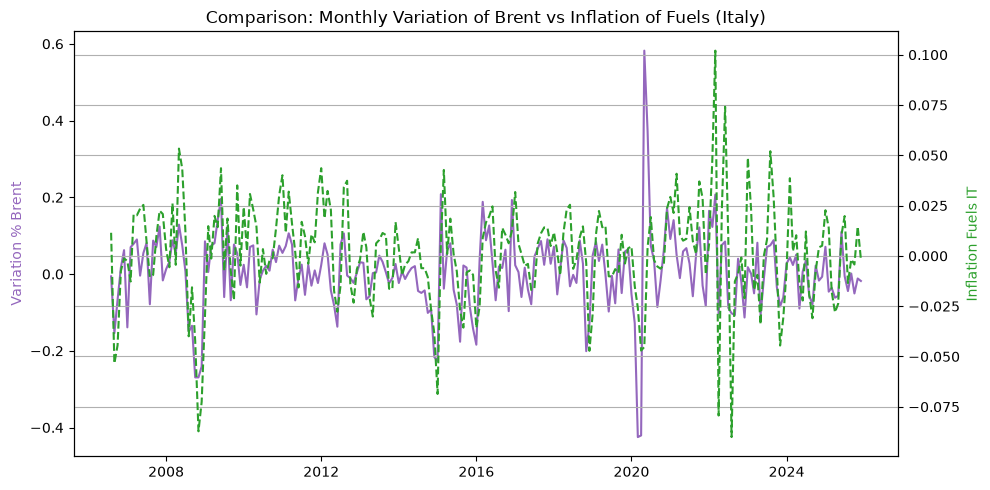

In [2]:
# ==========================================
# 2. TRANSFORMATION AND DATA PREPARATION
# ==========================================

# Compute the monthly percentage change (Month-over-Month Inflation)
# pct_change() calculates ((current_value - previous_value) / previous_value)
df_part2['target_transport_inflation_MoM'] = df_part2['hicp_transport_fuels_it'].pct_change()
df_part2['target_heating_inflation_MoM'] = df_part2['hicp_heating_it'].pct_change()

# Convert market prices to percentage changes
for col in market_series:
    df_part2[f'{col}_pct_change'] = df_part2[col].pct_change()

# Remove the first row that became null due to pct_change()
df_part2 = df_part2.dropna()

# Visualize the relationship between the change in Brent and the inflation of fuels in Italy
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df_part2.index, df_part2['brent_pct_change'], color='tab:purple', label='Variation % Brent (Market)', alpha=1.0)
ax1.set_ylabel('Variation % Brent', color='tab:purple')

ax2 = ax1.twinx()
ax2.plot(df_part2.index, df_part2['target_transport_inflation_MoM'], color='tab:green', label='Inflation Fuels IT (HICP)', linestyle='--', alpha=1.0)
ax2.set_ylabel('Inflation Fuels IT', color='tab:green')

plt.title('Comparison: Monthly Variation of Brent vs Inflation of Fuels (Italy)')
fig.tight_layout()
plt.grid(True)
plt.show()

The chart shows a clear correlation between movements in Brent crude and fuel inflation in Italy.

Eurostat publishes inflation figures halfway through the following month. If it is the 15th of the current month, we only have half of the market averages for the first 15 days, but we want to predict the total inflation for the month.

Which characteristics should we identify and use for our predictions: the percentage change from the previous month, or the market average for the current month?

## 3. Feature Selection Strategy for Nowcasting

Given that we are simulating a scenario in which we are halfway through the month (e.g. the 15th), the information available to predict inflation for the current month (t) would be:

- **1. Complete data for the previous month (t - 1):**
    - Monthly percentage change across all markets in month t – 1
    - Inflation for month t – 1 (which would already have been published)
- **2. Partial data for the current month (t):**
    - Given that the models for the first part are already available, it is possible to forecast the remainder of the month and calculate an ‘estimated average’ for month t. However, a more direct and robust approach, requiring fewer assumptions, is to use the **average of the first N days (e.g. 15 days)** of the current month compared with the average of the previous month

To keep this straightforward, the model is built using **lags** from the previous full month, as this information is reliable and confirmed.


R2 in Training: 0.3909
R2 in Test (Last 2 years): 0.2278
R2 in Test (Random Forest): 0.1680


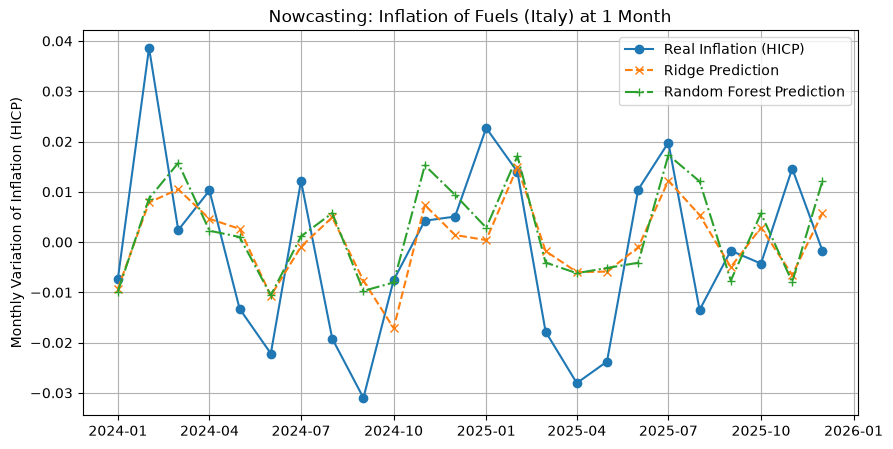


Importance of the Variables (Ridge Coefficients):


us_gasoline_spot_pct_change_lag1       0.052585
us_diesel_spot_pct_change_lag1         0.035423
heating_oil_ny_pct_change_lag1         0.027418
brent_pct_change_lag1                  0.020089
wti_pct_change_lag1                    0.012971
target_transport_inflation_MoM_lag1    0.005168
eurusd_pct_change_lag1                 0.001037
dtype: float64


Importance of the Variables (Random Forest Feature Importance):


us_gasoline_spot_pct_change_lag1       0.345874
heating_oil_ny_pct_change_lag1         0.233791
us_diesel_spot_pct_change_lag1         0.157020
wti_pct_change_lag1                    0.114068
brent_pct_change_lag1                  0.068324
eurusd_pct_change_lag1                 0.041817
target_transport_inflation_MoM_lag1    0.039104
dtype: float64

In [ ]:
# ==========================================
# 3. MODEL FITTING AND EVALUATION
# ==========================================

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Create Predictor Variables (Features)
# Use the percentage change from the previous month (t-1) for all markets
features = [f'{col}_pct_change' for col in market_series]

# Create lags of 1 month for the market features
for feature in features:
    df_part2[f'{feature}_lag1'] = df_part2[feature].shift(1)

# Add also the lag of the target variable itself (inflation from the previous month)
df_part2['target_transport_inflation_MoM_lag1'] = df_part2['target_transport_inflation_MoM'].shift(1)

# 2. Define Final Features and Target
# Discard the rows with null values created by the lag
df_model2 = df_part2.dropna().copy()

# For the independent variables, we will use the lags of the market features and the lag of the inflation
X_cols = [f'{col}_lag1' for col in features] + ['target_transport_inflation_MoM_lag1']
y_col = 'target_transport_inflation_MoM'

X = df_model2[X_cols]
y = df_model2[y_col]

# 3. Division Train/Test (Cronologic way, not random)
# Check the last 24 months (2 years) for evaluation
test_size = 24
train_size = len(df_model2) - test_size

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 4. Training of the Model (Ridge Regression)
# Ridge helps prevent overfitting (overfitting) by penalizing large coefficients
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

# 5. Training of the Model (Random Forest Regressor)
model_rf = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
model_rf.fit(X_train, y_train)

# 6. Prediction and Evaluation Ridge Regression
y_pred_train = model_ridge.predict(X_train)
y_pred_test = model_ridge.predict(X_test)

# Prediction and Evaluation Random Forest
y_pred_train_rf = model_rf.predict(X_train)
y_pred_test_rf = model_rf.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)

print(f"R2 in Training: {r2_train:.4f}")
print(f"R2 in Test (Last 2 years - Ridge): {r2_test:.4f}")
print(f"R2 in Test (Last 2 years - Random Forest): {r2_test_rf:.4f}")

# 7. Visualization of the Prediction
plt.figure(figsize=(10, 5))
plt.plot(df_model2.index[-test_size:], y_test, label='Real Inflation (HICP)', marker='o')
plt.plot(df_model2.index[-test_size:], y_pred_test, label='Ridge Prediction', linestyle='--', marker='x')
plt.plot(df_model2.index[-test_size:], y_pred_test_rf, label='Random Forest Prediction', linestyle='-.', marker='+')
plt.title('Nowcasting: Inflation of Fuels (Italy) at 1 Month')
plt.ylabel('Monthly Variation of Inflation (HICP)')
plt.legend()
plt.grid(True)
plt.show()

# 8. Coeficients Importance (Coefficients Ridge)
coefs = pd.Series(model_ridge.coef_, index=X_cols).sort_values(ascending=False)
print("\nImportance of the Variables (Ridge Coefficients):")
display(coefs)

# 9. Feature Importance (Random Forest)
importances = pd.Series(model_rf.feature_importances_, index=X_cols).sort_values(ascending=False)
print("\nImportance of the Variables (Random Forest Feature Importance):")
display(importances)

- **R-squared (R²):** A positive R² indicates that the model has predictive power compared to a naive model.
- **Coefficients:** The table of coefficients shows that the variable from last month that influenced the current month was **us_gasoline_spot_pct_change_lag1**, which carries much more weight than **brent**; this makes more sense given that it is closer to the consumer in the supply chain.
- **If there are increases**: for example, if the coefficient for **us_gasoline_spot** is 0.048033, this means that for every 100 per cent (1.0) increase in the market price of petrol, monthly fuel inflation in Italy will rise by 4.8 per cent.
- **In more realistic terms:** If petrol prices rise by 10 per cent (0.10) in month (t - 1), we expect Italian inflation in month t to rise by 0.48 per cent

## Performance evaluation (R² metric)

- **Signal-to-noise ratio:** An R² of 0.2252 on the test set for predicting economic percentage changes is an acceptable result. This model is managing to explain almost 23 per cent of the variance in fuel inflation based purely on data that is one month behind.
- **Model generalisation:** The difference between the training (0.3790) and test (0.2252) R² values indicates a degree of overfitting. However, it confirms that the model succeeded in extracting a genuine underlying pattern rather than merely memorising past data.

## Graphical behaviour and conservative models

- **The smoothing effect:** The fact that the forecast follows the trend but does not reach the exact magnitude of the peaks is an inherent mathematical characteristic of **Ridge Regression**. This algorithm penalises large weights, resulting in conservative forecasts that tend to revert to the mean
- **External shocks:** Pronounced spikes in actual inflation are often the result of sudden macroeconomic events or abrupt logistical disruptions that a model based on lagged monthly averages simply cannot anticipate.

## Economic History (Importance of the coefficients)

- **Refined products versus crude oil:** us_gasoline_spot (0.048) and us_diesel_spot (0.034) are the strongest predictors, outperforming Brent (0.020). This is understandable given that petrol and diesel are refined products. They already incorporate refining costs and margins, bringing them one step closer to the final price paid by consumers in Italy compared with extracted crude oil.
- **Non-inertial inflation:** The almost negligible weight of the previous month’s inflation (0.005) demonstrates that fuel prices at petrol stations react almost exclusively to current conditions on the international market, without carrying over any inertia from previous months.